In [1]:
!pip install pandas numpy scikit-learn matplotlib

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

print("✅ Done!")

✅ Done!


In [4]:
df = pd.read_csv("pneumonia_dataset.csv")

print("Total patients :", len(df))
print("Normal         :", len(df[df['label']==0]))
print("Pneumonia      :", len(df[df['label']==1]))
print(df.head(3))

Total patients : 1000
Normal         : 500
Pneumonia      : 500
   age  temperature_C  heart_rate  respiratory_rate  oxygen_saturation  \
0   16           39.3         110                24               93.9   
1   62           38.1         116                26               90.5   
2   58           38.9          87                22               91.3   

   wbc_count  cough  chest_pain  fatigue  shortness_of_breath  label  
0       10.9      1           0        1                    1      1  
1        9.1      1           1        1                    1      1  
2       20.2      1           1        0                    0      1  


In [5]:
df.tail

<bound method NDFrame.tail of      age  temperature_C  heart_rate  respiratory_rate  oxygen_saturation  \
0     16           39.3         110                24               93.9   
1     62           38.1         116                26               90.5   
2     58           38.9          87                22               91.3   
3     35           38.5         107                21               95.3   
4     52           37.0          63                18               96.7   
..   ...            ...         ...               ...                ...   
995   37           36.5          73                16               98.9   
996   54           37.3          88                14               97.3   
997   33           39.1          83                19               93.6   
998   40           37.5          64                15               98.3   
999   33           37.5          75                15              100.0   

     wbc_count  cough  chest_pain  fatigue  shortness_of_

In [7]:
df.info

<bound method DataFrame.info of      age  temperature_C  heart_rate  respiratory_rate  oxygen_saturation  \
0     16           39.3         110                24               93.9   
1     62           38.1         116                26               90.5   
2     58           38.9          87                22               91.3   
3     35           38.5         107                21               95.3   
4     52           37.0          63                18               96.7   
..   ...            ...         ...               ...                ...   
995   37           36.5          73                16               98.9   
996   54           37.3          88                14               97.3   
997   33           39.1          83                19               93.6   
998   40           37.5          64                15               98.3   
999   33           37.5          75                15              100.0   

     wbc_count  cough  chest_pain  fatigue  shortness_o

In [8]:
df.isnull().sum()

age                    0
temperature_C          0
heart_rate             0
respiratory_rate       0
oxygen_saturation      0
wbc_count              0
cough                  0
chest_pain             0
fatigue                0
shortness_of_breath    0
label                  0
dtype: int64

In [9]:
df.describe

<bound method NDFrame.describe of      age  temperature_C  heart_rate  respiratory_rate  oxygen_saturation  \
0     16           39.3         110                24               93.9   
1     62           38.1         116                26               90.5   
2     58           38.9          87                22               91.3   
3     35           38.5         107                21               95.3   
4     52           37.0          63                18               96.7   
..   ...            ...         ...               ...                ...   
995   37           36.5          73                16               98.9   
996   54           37.3          88                14               97.3   
997   33           39.1          83                19               93.6   
998   40           37.5          64                15               98.3   
999   33           37.5          75                15              100.0   

     wbc_count  cough  chest_pain  fatigue  shortness

In [10]:
df.columns

Index(['age', 'temperature_C', 'heart_rate', 'respiratory_rate',
       'oxygen_saturation', 'wbc_count', 'cough', 'chest_pain', 'fatigue',
       'shortness_of_breath', 'label'],
      dtype='object')

In [11]:
X = df.drop('label', axis=1)
y = df['label']

print("X shape :", X.shape)
print("y shape :", y.shape)

X shape : (1000, 10)
y shape : (1000,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Train size :", len(X_train))
print("Test size  :", len(X_test))

Train size : 800
Test size  : 200


In [13]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("✅ Model trained!")

✅ Model trained!


In [14]:
y_pred = model.predict(X_test)
acc    = accuracy_score(y_test, y_pred) * 100
cm     = confusion_matrix(y_test, y_pred)

print(f"🎯 Accuracy = {acc:.2f}%")
print()
print("Correctly said Normal    (TN) =", cm[0,0])
print("Correctly said Pneumonia (TP) =", cm[1,1])
print("Wrong predictions        (FP) =", cm[0,1])
print("Missed cases             (FN) =", cm[1,0])
print()
print(classification_report(y_test, y_pred, target_names=['Normal','Pneumonia']))

🎯 Accuracy = 100.00%

Correctly said Normal    (TN) = 100
Correctly said Pneumonia (TP) = 100
Wrong predictions        (FP) = 0
Missed cases             (FN) = 0

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       100
   Pneumonia       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [15]:
patients = {
    "Sick Patient   ": [68, 39.4, 110, 28, 90.0, 15.0, 1, 1, 1, 1],
    "Healthy Patient": [28, 36.8,  70, 15, 98.9,  6.2, 0, 0, 0, 0],
    "Unsure Patient ": [45, 38.2,  88, 20, 95.0,  9.8, 1, 0, 1, 0],
}

for name, values in patients.items():
    p      = scaler.transform([values])
    pred   = model.predict(p)[0]
    prob   = model.predict_proba(p)[0]
    result = "🔴 PNEUMONIA" if pred == 1 else "🟢 NORMAL"
    print(f"{name} → {result}")
    print(f"  Normal chance    : {prob[0]*100:.1f}%")
    print(f"  Pneumonia chance : {prob[1]*100:.1f}%")
    print()

Sick Patient    → 🔴 PNEUMONIA
  Normal chance    : 0.0%
  Pneumonia chance : 100.0%

Healthy Patient → 🟢 NORMAL
  Normal chance    : 100.0%
  Pneumonia chance : 0.0%

Unsure Patient  → 🔴 PNEUMONIA
  Normal chance    : 27.3%
  Pneumonia chance : 72.7%



C:\Users\User\anaconda6\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\User\anaconda6\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\User\anaconda6\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


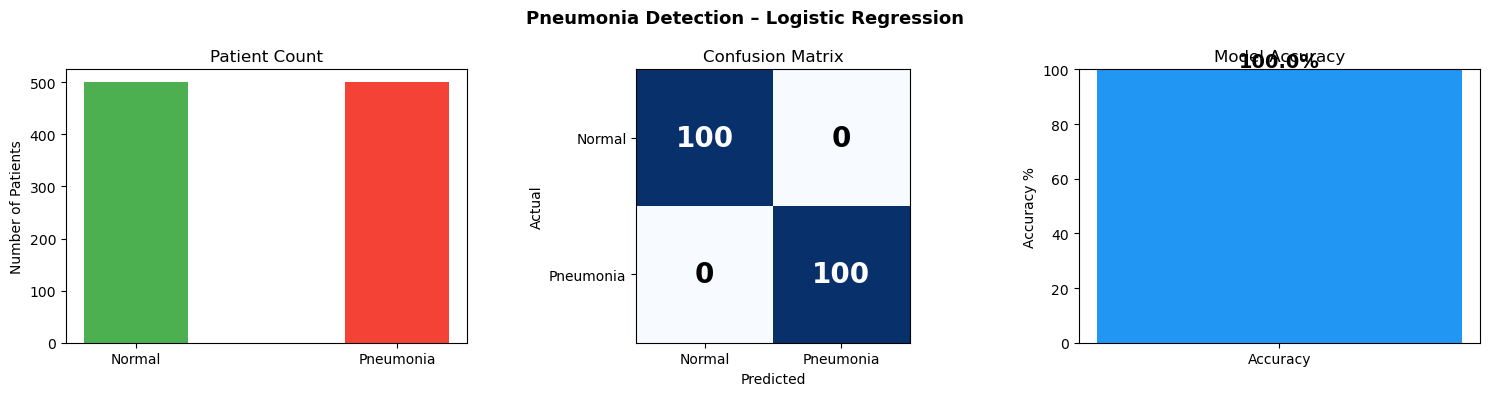

✅ All Done! 🎉


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Pneumonia Detection – Logistic Regression", fontsize=13, fontweight='bold')

# Graph 1 : Patient Count
ax1 = axes[0]
ax1.bar(['Normal', 'Pneumonia'],
        [len(df[df['label']==0]), len(df[df['label']==1])],
        color=['#4CAF50', '#F44336'], width=0.4)
ax1.set_title("Patient Count")
ax1.set_ylabel("Number of Patients")

# Graph 2 : Confusion Matrix
ax2 = axes[1]
ax2.imshow(cm, cmap='Blues')
ax2.set_title("Confusion Matrix")
ax2.set_xticks([0,1]); ax2.set_yticks([0,1])
ax2.set_xticklabels(['Normal','Pneumonia'])
ax2.set_yticklabels(['Normal','Pneumonia'])
ax2.set_xlabel("Predicted"); ax2.set_ylabel("Actual")
for i in range(2):
    for j in range(2):
        ax2.text(j, i, cm[i,j], ha='center', va='center',
                 fontsize=20, fontweight='bold',
                 color='white' if cm[i,j] > 50 else 'black')

# Graph 3 : Accuracy
ax3 = axes[2]
ax3.bar(['Accuracy'], [acc], color='#2196F3', width=0.3)
ax3.set_ylim(0, 100)
ax3.set_ylabel("Accuracy %")
ax3.set_title("Model Accuracy")
ax3.text(0, acc+1, f"{acc:.1f}%", ha='center', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()
print("✅ All Done! 🎉")

In [17]:
print("===== MODEL CHECK =====")
print(f"Accuracy = {acc:.2f}%")

if acc >= 95:
    print("✅ Model is EXCELLENT!")
elif acc >= 80:
    print("⚠️ Model is OK but can improve")
else:
    print("❌ Model needs fixing")

===== MODEL CHECK =====
Accuracy = 100.00%
✅ Model is EXCELLENT!


In [18]:
very_sick = [[70, 40.0, 120, 30, 88.0, 18.0, 1, 1, 1, 1]]
p = scaler.transform(very_sick)
result = model.predict(p)[0]
print(f"Very Sick Patient   → {'🔴 PNEUMONIA ✅' if result==1 else '❌ WRONG ANSWER'}")

# Very healthy patient - should ALWAYS say Normal
very_healthy = [[25, 36.5, 68, 14, 99.0, 5.5, 0, 0, 0, 0]]
p = scaler.transform(very_healthy)
result = model.predict(p)[0]
print(f"Very Healthy Patient → {'🟢 NORMAL ✅' if result==0 else '❌ WRONG ANSWER'}")


Very Sick Patient   → 🔴 PNEUMONIA ✅
Very Healthy Patient → 🟢 NORMAL ✅


C:\Users\User\anaconda6\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\User\anaconda6\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
